In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 172k/172k [00:00<00:00, 311kB/s]

Extracting files...
Path to dataset files: C:\Users\User\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


In [3]:
import os
print(os.listdir(path))

['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [4]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# 1. Correctly combine the path and the file name using os.path.join
csv_path = os.path.join(path, 'WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = pd.read_csv(csv_path)

# 2. Data Cleaning
df.drop('customerID', axis=1, inplace=True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df = pd.get_dummies(df, drop_first=True)

# 3. Features & Target Split
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Model Training & Evaluation
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "k-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Support Vector Machine": SVC(kernel='rbf')
}

print("Training and evaluating models...\n")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    print(f"=== {name} ===")
    print(f"Accuracy: {accuracy_score(y_test, predictions):.4f}")
    print(classification_report(y_test, predictions))
    print("-" * 50)

Training and evaluating models...

=== Logistic Regression ===
Accuracy: 0.8197
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409

--------------------------------------------------
=== k-Nearest Neighbors ===
Accuracy: 0.7708
              precision    recall  f1-score   support

           0       0.83      0.86      0.85      1036
           1       0.57      0.52      0.55       373

    accuracy                           0.77      1409
   macro avg       0.70      0.69      0.70      1409
weighted avg       0.76      0.77      0.77      1409

--------------------------------------------------
=== Support Vector Machine ===
Accuracy: 0.8141
              precision    recall  f1-score   support

           0    

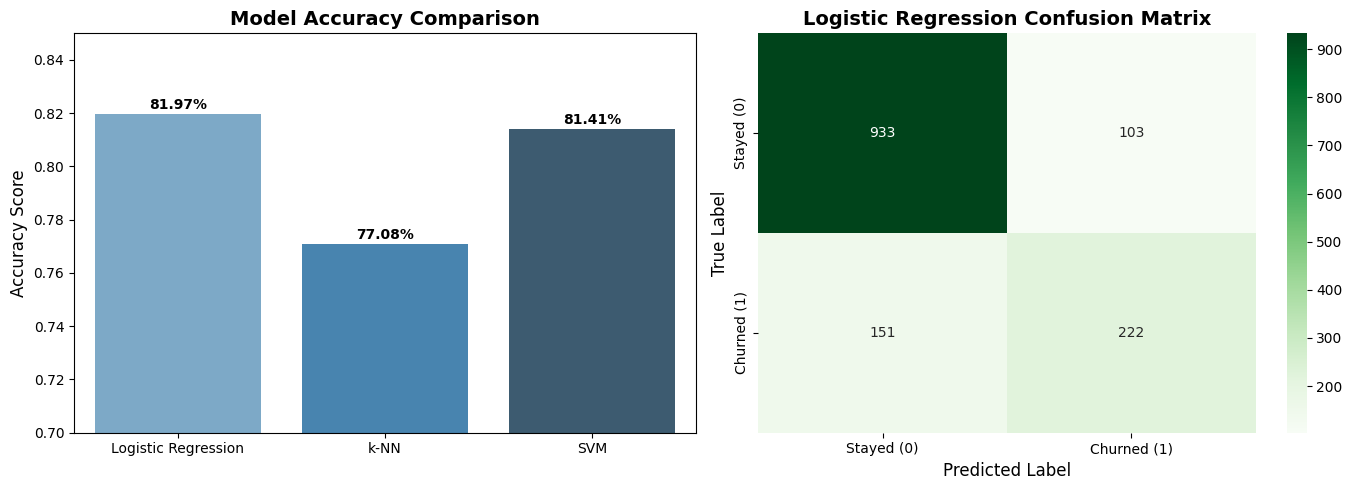

In [5]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. Load and Clean Data
csv_path = os.path.join(path, 'WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = pd.read_csv(csv_path)

df.drop('customerID', axis=1, inplace=True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df = pd.get_dummies(df, drop_first=True)

# 2. Split and Scale
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Re-train the Winning Model (Logistic Regression) for the plot
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

# 4. Prepare Data for Accuracy Plot
model_names = ['Logistic Regression', 'k-NN', 'SVM']
accuracies = [0.8197, 0.7708, 0.8141]

# Create the figure setup
plt.figure(figsize=(14, 5))

# Plot 1: Bar Chart of Accuracies (Fixed the palette warning here)
plt.subplot(1, 2, 1)
sns.barplot(x=model_names, y=accuracies, hue=model_names, palette='Blues_d', legend=False)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy Score', fontsize=12)
plt.ylim(0.7, 0.85) 
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.002, f"{v*100:.2f}%", ha='center', fontweight='bold')

# Plot 2: Confusion Matrix for the Winner
plt.subplot(1, 2, 2)
log_preds = log_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, log_preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Stayed (0)', 'Churned (1)'], 
            yticklabels=['Stayed (0)', 'Churned (1)'])
plt.title('Logistic Regression Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.show()